# 2. Which pair should be measured?

Notebook 1 ranked residues: it said where a dye can go. An experiment does not
measure a residue, it measures a *pair*, and the two questions have different
answers. A pair is worth the mutation when three things hold at once:

1. both sites can carry a dye -- that is the label score, from notebook 1;
2. the dye-dye distance sits where FRET responds to it, near $R_0$;
3. and, if the point is a conformational change, that distance **changes**
   between the two states.

The Labelizer has a score for each of the last two. `labelizer_fret_pair_scores`
answers the one-state question,

$$ \text{score} = \text{jls}\cdot\bigl(1 - 2\,|E - \tfrac12|\bigr), $$

which peaks where the transfer efficiency is one half, and
`labelizer_pair_scores_two_states` answers the two-state question,

$$ \text{score} = \text{jls}\cdot |E_1 - E_2|, $$

which peaks where the efficiency moves most. `jls` is the *joined label score*
of the sites -- the labelability of notebook 1, carried into the pair.

This notebook runs both on BmrA, compares them, and then checks the winners
against accessible volumes built independently of the screen. The comparison
does not come out clean, and the places where it does not are the useful part.

In [1]:
%matplotlib inline
import contextlib, os, pathlib, sys, tempfile, time

import numpy as np
import matplotlib.pyplot as plt

import IMP.bff as bff

# workshop.py sits beside this notebook; nbconvert may be run from anywhere.
for candidate in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
    if (candidate / "workshop.py").exists():
        sys.path.insert(0, str(candidate)); break
    if (candidate / "doc" / "workshop" / "workshop.py").exists():
        sys.path.insert(0, str(candidate / "doc" / "workshop")); break
import workshop as ws


@contextlib.contextmanager
def quiet():
    # Building one accessible volume prints a PDB-read banner, and this
    # notebook builds a few hundred. The banners are written to the process's
    # file descriptors, not to sys.stdout, so they are closed off there.
    saved, devnull = [os.dup(1), os.dup(2)], os.open(os.devnull, os.O_WRONLY)
    sys.stdout.flush(); sys.stderr.flush()
    os.dup2(devnull, 1); os.dup2(devnull, 2)
    try:
        yield
    finally:
        sys.stdout.flush(); sys.stderr.flush()
        os.dup2(saved[0], 1); os.dup2(saved[1], 2)
        for fd in (devnull, *saved):
            os.close(fd)


print("build:", bff.get_build(), "| version:", bff.get_module_version())
paths = {state: str(ws.single_dimer(state)) for state in ("closed", "open")}
for state, path in paths.items():
    print(f"{state:7s} {ws.STATES[state]['pdb_id']}  {ws.STATES[state]['note']}")

build: imp | version: ab5de21
closed  6R72  outward-facing, E504A, ATP/Mg (X-ray)
open    8QOE  inward-facing (cryo-EM)


## The label scores again, in two lines

Notebook 1 established the model this workshop uses: the published one with the
conservation term removed, because BmrA has no ConSurf grades and the terms
multiply, so leaving `cs` in returns exactly zero for every residue. Nothing
here re-derives that; the scores are simply recomputed.

`labelizer_combined_by_key` returns the combination keyed the way the pair
functions want it -- `"A428"`, chain and residue number in one string.

In [2]:
model = bff.LabelizerParameterList()
for parameter in bff.labelizer_model_paper():
    if parameter.tag != "cs":
        model.append(parameter)
print("model:", [(p.tag, p.weight) for p in model])

with quiet():
    rows = {state: bff.labelizer_score_structure(path, model, bff.LabelizerOptions(), "")
            for state, path in paths.items()}
label_scores = {state: bff.labelizer_combined_by_key(scored) for state, scored in rows.items()}
by_site = {state: dict(table) for state, table in label_scores.items()}   # a plain dict to look in

THRESHOLD = 1.5            # the shortlist threshold of notebook 1
for state, table in label_scores.items():
    values = np.array(list(table.values()))
    print(f"{state:7s} {len(values):5d} scored, {values.min():.2f}-{values.max():.2f}, "
          f"{(values >= THRESHOLD).sum():4d} at or above {THRESHOLD}")

model: [('se', 1), ('tp', 0), ('cr', 1), ('ss', 1), ('ce', 0)]


closed   1140 scored, 0.00-1.90,  125 at or above 1.5
open     1136 scored, 0.00-2.07,  159 at or above 1.5


## The dye, and what the screen is allowed to cost

The pair functions carry their own dye geometry, and its defaults are not this
workshop's dye: `LabelizerFRETOptions` starts at a 9 A probe radius, where
`workshop.DYES["Alexa488"]` uses 3.5 A. A 9 A sphere does not fit beside a
tight site, so with the defaults a number of BmrA sites come back with an empty
volume. The options below are set to the workshop's Alexa488 so that the screen
and the cross-check later on are talking about the same molecule.

`label_score_threshold` is the other lever. Its default of 0.5 leaves about a
thousand BmrA residues in play and therefore half a million pairs; the
threshold from notebook 1 leaves 125 sites in the closed state, which is 7750
pairs, and those are the sites anyone would actually mutate.

In [3]:
def fret_options(**overrides):
    # The workshop's Alexa488 geometry, in the fields the pair screen reads.
    dye = ws.DYES["Alexa488"]
    options = bff.LabelizerFRETOptions()
    options.forster_radius = ws.R0
    options.label_score_threshold = THRESHOLD
    options.linker_length = dye["linker_length"]
    options.linker_width = dye["linker_width"]
    options.r1, options.r2, options.r3 = dye["av1_radius"], 0.0, 0.0
    options.n_refine = 0
    for name, value in overrides.items():
        setattr(options, name, value)
    return options


def name(p):
    return f"{p.asym_id_1}{p.seq_id_1}-{p.asym_id_2}{p.seq_id_2}"


def key(p):
    return (p.asym_id_1, p.seq_id_1, p.asym_id_2, p.seq_id_2)


base = fret_options()
print(f"R0 = {base.forster_radius:.0f} A, linker {base.linker_length:.0f}/"
      f"{base.linker_width:.1f} A, probe radius {base.r1:.1f} A, "
      f"grid {base.grid_resolution:.1f} A")
print(f"distance reported: {base.distance_type}   "
      f"(Rmp <= RDAMeanE <= <R_DA>; RDAMeanE is what a FRET experiment measures)")

R0 = 52 A, linker 20/4.5 A, probe radius 3.5 A, grid 1.5 A
distance reported: RDAMeanE   (Rmp <= RDAMeanE <= <R_DA>; RDAMeanE is what a FRET experiment measures)


## One state: where is the efficiency one half?

The screen places a dye at every site above the threshold, forms every pair,
and scores it. With `n_refine = 0` the dye is the reference's analytic **alpha
cone**: a point on the outward normal from the C-beta, pushed out by a fraction
of the linker length that shrinks as the site gets buried. One neighbour search
per site, so the whole screen is instant.

In [4]:
t0 = time.time()
with quiet():
    cone = list(bff.labelizer_fret_pair_scores(paths["closed"], label_scores["closed"],
                                               fret_options()))
n_sites = int(round((1 + (1 + 8 * len(cone)) ** 0.5) / 2))
print(f"{len(cone)} pairs from {n_sites} labelable sites, in {time.time() - t0:.1f} s")

print(f"\n{'pair':<14} {'score':>7} {'jls':>6} {'d / A':>7} {'E':>6}")
for p in cone[:10]:
    print(f"{name(p):<14} {p.value:7.4f} {p.joined_label_score:6.3f} {p.distance:7.1f} "
          f"{ws.efficiency(p.distance):6.3f}")

# The formula, checked once on the top row.
p = cone[0]
e = ws.efficiency(p.distance)
print(f"\njls * (1 - 2|E - 0.5|) = {p.joined_label_score:.4f} * "
      f"{1 - 2 * abs(e - 0.5):.4f} = {p.joined_label_score * (1 - 2 * abs(e - 0.5)):.4f}"
      f"   reported {p.value:.4f}")

7750 pairs from 125 labelable sites, in 0.0 s

pair             score    jls   d / A      E
A436-B566       1.8325  1.843    52.1  0.497
A436-B428       1.7538  1.850    52.9  0.474
A428-B25        1.7225  1.750    52.3  0.492
A66-B60         1.7005  1.758    51.4  0.516
A60-B63         1.6960  1.703    52.1  0.498
A394-A436       1.6948  1.752    52.6  0.484
A248-B333       1.6945  1.711    52.2  0.495
A25-B421        1.6936  1.697    52.0  0.501
A462-B10        1.6911  1.713    52.2  0.494
A428-B436       1.6908  1.850    53.5  0.457

jls * (1 - 2|E - 0.5|) = 1.8427 * 0.9944 = 1.8325   reported 1.8325


### The second tier: rebuild the best few with a real volume

The cone is a point. A dye is a cloud, and the distance between two clouds is
not the distance between their two mean positions -- the screen reports
`RDAMeanE`, the distance that reproduces the mean transfer efficiency, which is
what an experiment measures. `n_refine` takes the top of the cone's list and
recomputes exactly those pairs with accessible volumes, rebuilding only the
sites those pairs use.

Because the score peaks sharply at $R = R_0$, a couple of Angstrom moves a pair
a long way down the list. That is the whole reason the second tier exists.

In [5]:
N_REFINE = 150
t0 = time.time()
with quiet():
    refined = list(bff.labelizer_fret_pair_scores(paths["closed"], label_scores["closed"],
                                                  fret_options(n_refine=N_REFINE)))
print(f"{N_REFINE} pairs rebuilt with accessible volumes in {time.time() - t0:.1f} s")

cone_rank = {key(p): i for i, p in enumerate(cone)}
cone_distance = {key(p): p.distance for p in cone}
cone_value = {key(p): p.value for p in cone}
new_rank = {key(p): i for i, p in enumerate(refined)}
av_rows = [p for p in refined if p.probe_model == bff.PROBE_MODEL_ACCESSIBLE_VOLUME]
print(f"rows carrying probe_model == PROBE_MODEL_ACCESSIBLE_VOLUME: {len(av_rows)}")

print(f"\nthe cone's ten best, after the rebuild")
print(f"{'pair':<14} {'d cone':>7} {'d AV':>7} {'change':>7} {'s cone':>7} {'s AV':>7} {'rank':>10}")
for p in cone[:10]:
    k = key(p)
    q = refined[new_rank[k]]
    print(f"{name(p):<14} {p.distance:7.1f} {q.distance:7.1f} {q.distance - p.distance:+7.1f} "
          f"{p.value:7.4f} {q.value:7.4f} {1:>4} ->{new_rank[k] + 1:>4}")

150 pairs rebuilt with accessible volumes in 6.9 s
rows carrying probe_model == PROBE_MODEL_ACCESSIBLE_VOLUME: 150

the cone's ten best, after the rebuild
pair            d cone    d AV  change  s cone    s AV       rank
A436-B566         52.1    55.4    +3.3  1.8325  1.4962    1 -> 212
A436-B428         52.9    53.1    +0.2  1.7538  1.7374    1 ->   1
A428-B25          52.3    52.7    +0.5  1.7225  1.6766    1 ->   6
A66-B60           51.4    51.4    -0.1  1.7005  1.6950    1 ->   5
A60-B63           52.1    46.4    -5.6  1.6960  1.1465    1 ->1219
A394-A436         52.6    57.0    +4.5  1.6948  1.2777    1 -> 829
A248-B333         52.2    59.4    +7.2  1.6945  1.0610    1 ->1488
A25-B421          52.0    56.0    +4.1  1.6936  1.3233    1 -> 701
A462-B10          52.2    52.9    +0.6  1.6911  1.6294    1 ->  17
A428-B436         53.5    53.7    +0.2  1.6908  1.6684    1 ->   8


In [6]:
print(f"the ten best after the rebuild")
print(f"{'pair':<14} {'score':>7} {'d / A':>7} {'was ranked':>11} {'d cone':>7}")
for p in refined[:10]:
    k = key(p)
    print(f"{name(p):<14} {p.value:7.4f} {p.distance:7.1f} {cone_rank[k] + 1:>11} "
          f"{cone_distance[k]:7.1f}")

the ten best after the rebuild
pair             score   d / A  was ranked  d cone
A436-B428       1.7374    53.1           2    52.9
A25-B10         1.7226    52.2         129    53.8
B113-B143       1.7015    52.0         130    53.4
B392-B428       1.7010    52.5          51    53.2
A66-B60         1.6950    51.4           4    51.4
A428-B25        1.6766    52.7           3    52.3
A351-B498       1.6716    51.5          27    52.7
A428-B436       1.6684    53.7          10    53.5
A440-B428       1.6582    52.2          26    51.9
B10-B440        1.6532    52.1          63    52.5


### Does the cone systematically over-reach?

The example script this material comes from says it does -- that the analytic
placement pushes the dye 2-5 A too far out. On BmrA that claim does not survive
contact with the numbers, and the way it fails is worth stating precisely.

In [7]:
shift = np.array([p.distance - cone_distance[key(p)] for p in av_rows])
print(f"AV minus cone over the {len(shift)} rebuilt pairs:")
print(f"   mean   {shift.mean():+.2f} A")
print(f"   median {np.median(shift):+.2f} A")
print(f"   range  {shift.min():+.2f} to {shift.max():+.2f} A")
print(f"   quartiles {np.percentile(shift, 25):+.2f} / {np.percentile(shift, 75):+.2f} A")
print(f"   shorter after the rebuild: {(shift < 0).sum()}/{len(shift)}, "
      f"longer: {(shift > 0).sum()}/{len(shift)}")
print(f"   within 2 A either way:     {(np.abs(shift) < 2).sum()}/{len(shift)}")

moved = np.array([new_rank[key(p)] - cone_rank[key(p)] for p in av_rows])
print(f"\nrank change of those pairs: median {int(np.median(moved)):+d}, "
      f"worst {moved.max():+d} places")
print(f"pairs that stayed in the top {N_REFINE}: "
      f"{sum(1 for p in av_rows if new_rank[key(p)] < N_REFINE)}/{len(av_rows)}")

AV minus cone over the 150 rebuilt pairs:
   mean   -3.13 A
   median -0.17 A
   range  -39.16 to +11.83 A
   quartiles -7.25 / +2.50 A
   shorter after the rebuild: 80/150, longer: 70/150
   within 2 A either way:     39/150

rank change of those pairs: median +745, worst +7510 places
pairs that stayed in the top 150: 33/150


There is no bias to speak of. The median shift is under a fifth of an Angstrom,
and the rebuild makes 80 of the 150 pairs shorter and 70 longer. What there is
instead is **scatter**, and a lot of it: only 39 of the 150 land within 2 A of
the cone's estimate, and the tail reaches nearly 40 A on the short side -- the
sites where the dye cannot in fact go where the outward normal points, because
something is in the way.

For a ranking that is worse than a bias would be. A bias shifts every pair
together and leaves the order alone. Scatter around a score that peaks sharply
at $R = R_0$ reshuffles the list: 117 of the 150 rebuilt pairs drop out of the
top 150 altogether, and the cone's own best pair ends up outside the top two
hundred. The second tier is not an optimisation, it is the difference between a
list and a guess.

One consequence of how the two tiers fit together: after the rebuild the list
mixes 150 accessible-volume rows with 7600 cone rows, so a demoted pair's new
rank is measured against competitors that have not been rebuilt. Refining
generously is cheap insurance -- these 150 pairs cost seven seconds.

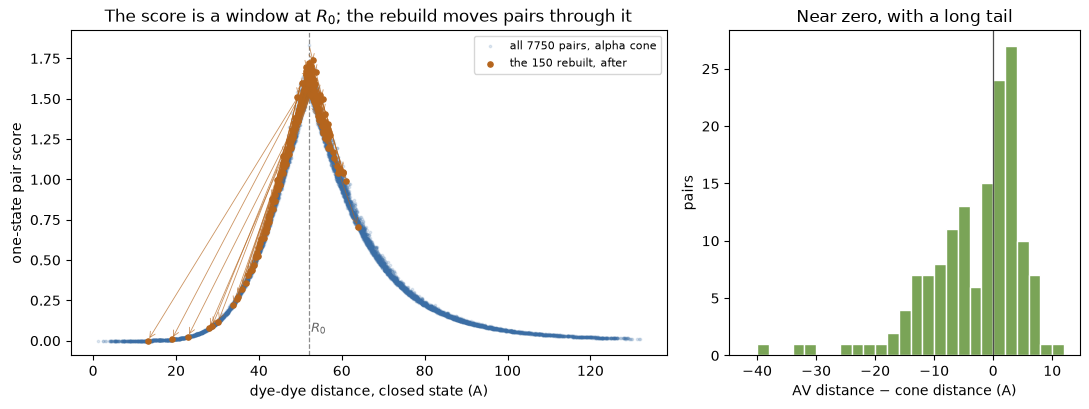

In [8]:
fig, (ax, bx) = plt.subplots(1, 2, figsize=(11, 4.2),
                             gridspec_kw={"width_ratios": [1.7, 1.0]})

ax.scatter([p.distance for p in cone], [p.value for p in cone], s=3, alpha=0.15,
           color="#3b6ea5", label=f"all {len(cone)} pairs, alpha cone")
for p in av_rows:
    k = key(p)
    ax.annotate("", xy=(p.distance, p.value), xytext=(cone_distance[k], cone_value[k]),
                arrowprops=dict(arrowstyle="->", color="#b5651d", lw=0.6, alpha=0.7))
ax.scatter([p.distance for p in av_rows], [p.value for p in av_rows], s=14,
           color="#b5651d", zorder=3, label=f"the {len(av_rows)} rebuilt, after")
ax.axvline(ws.R0, color="0.55", lw=0.9, ls="--")
ax.text(ws.R0 + 0.6, 0.05, "$R_0$", color="0.4", fontsize=9)
ax.set_xlabel("dye-dye distance, closed state (A)")
ax.set_ylabel("one-state pair score")
ax.set_title("The score is a window at $R_0$; the rebuild moves pairs through it")
ax.legend(fontsize=8, loc="upper right")

bx.hist(shift, bins=np.arange(-42, 14, 2), color="#7aa457", edgecolor="white")
bx.axvline(0, color="0.3", lw=0.9)
bx.set_xlabel("AV distance $-$ cone distance (A)")
bx.set_ylabel("pairs")
bx.set_title("Near zero, with a long tail")
fig.tight_layout()
plt.show()

## Two states: which pair reports on the transition?

This is the question the workshop is actually about. BmrA's two structures
differ by the closure of the nucleotide-binding domains, and a pair is
informative when the efficiency it reports is *different* in the two.

`labelizer_pair_scores_two_states` takes both structures and both score tables,
matches positions by chain and residue number, and scores each pair by
$\text{jls}\cdot|E_1 - E_2|$. Only positions present above the threshold in both
states survive, which is why the list is shorter than the one-state one.

In [9]:
t0 = time.time()
with quiet():
    two_cone = list(bff.labelizer_pair_scores_two_states(
        paths["closed"], paths["open"], label_scores["closed"], label_scores["open"],
        fret_options()))
n_sites = int(round((1 + (1 + 8 * len(two_cone)) ** 0.5) / 2))
print(f"{len(two_cone)} pairs from {n_sites} sites present in both states, "
      f"in {time.time() - t0:.1f} s")

print(f"\n{'pair':<14} {'score':>7} {'jls':>6} {'d closed':>9} {'d open':>8} {'dE':>7}")
for p in two_cone[:10]:
    de = ws.efficiency(p.distance_2) - ws.efficiency(p.distance)
    print(f"{name(p):<14} {p.value:7.4f} {p.joined_label_score:6.3f} {p.distance:9.1f} "
          f"{p.distance_2:8.1f} {de:+7.3f}")

p = two_cone[0]
change = abs(ws.efficiency(p.distance) - ws.efficiency(p.distance_2))
print(f"\njls * |E1 - E2| = {p.joined_label_score:.4f} * {change:.4f} = "
      f"{p.joined_label_score * change:.4f}   reported {p.value:.4f}")

2926 pairs from 77 sites present in both states, in 0.0 s

pair             score    jls  d closed   d open      dE
A351-B436       2.0560  3.231      30.5     58.7  -0.636
A440-B351       1.9739  2.856      35.8     64.7  -0.691
A299-B428       1.8676  2.813      60.1     30.7  +0.664
A428-B299       1.8591  2.813      60.0     30.8  +0.661
A351-B440       1.8566  2.856      38.1     64.5  -0.650
A392-B436       1.8534  3.322      46.1     72.9  -0.558
A299-B474       1.8238  2.599      62.2     31.1  +0.702
A394-B436       1.8006  2.963      42.4     68.2  -0.608
A474-B299       1.7946  2.599      61.7     31.2  +0.691
A376-A428       1.7513  3.461      57.8     38.9  +0.506

jls * |E1 - E2| = 3.2310 * 0.6363 = 2.0560   reported 2.0560


### The joined label score is squared here

Note the `jls` column: it runs above 3, where no single-state pair went above
1.9. The published arithmetic raises the *product* of the label scores to the
power one half whatever the count, and a two-state pair has four of them --
both sites in both states. For four scores near 1.7 that is $1.7^2$, not 1.7.

So the one-state and the two-state scores are **not on a common scale**, and a
number from one list cannot be compared with a number from the other.
`LABELIZER_MODEL_CORRECTED` uses the exponent $1/N$ instead, which is the line
the reference has commented out immediately below the one it runs.

In [10]:
p = two_cone[0]
parts = [label_scores["closed"][f"{p.asym_id_1}{p.seq_id_1}"],
         label_scores["closed"][f"{p.asym_id_2}{p.seq_id_2}"],
         label_scores["open"][f"{p.asym_id_1}{p.seq_id_1}"],
         label_scores["open"][f"{p.asym_id_2}{p.seq_id_2}"]]
print(f"{name(p)}: label scores {', '.join(f'{v:.3f}' for v in parts)}")
print(f"  published  prod^(1/2)   = {np.prod(parts) ** 0.5:.4f}   (reported "
      f"{p.joined_label_score:.4f})")
print(f"  corrected  prod^(1/4)   = {np.prod(parts) ** 0.25:.4f}")

A351-B436: label scores 1.650, 1.896, 1.891, 1.765
  published  prod^(1/2)   = 3.2310   (reported 3.2310)
  corrected  prod^(1/4)   = 1.7975


### There is no refinement tier here

`labelizer_fret_pair_scores` screens with the cone and rebuilds the best few
with volumes. `labelizer_pair_scores_two_states` does not: it places every site
once with `probe_model` and stops. Setting `n_refine` on it changes nothing,
and the cell below shows that rather than asserting it.

That is not a gap that has to be worked around, because the cost of an
accessible-volume screen is linear in *sites*, not in pairs -- each site's cloud
is built once and reused for every pair it appears in. With 77 sites in two
states it is 154 volumes, about half a minute, and then the whole list is exact.

In [11]:
with quiet():
    attempted = list(bff.labelizer_pair_scores_two_states(
        paths["closed"], paths["open"], label_scores["closed"], label_scores["open"],
        fret_options(n_refine=150)))
print("any row rebuilt with a volume:",
      any(p.probe_model == bff.PROBE_MODEL_ACCESSIBLE_VOLUME for p in attempted))
print("order identical to n_refine = 0:",
      [key(p) for p in attempted] == [key(p) for p in two_cone])

any row rebuilt with a volume: False
order identical to n_refine = 0: True


In [12]:
t0 = time.time()
with quiet():
    two_av = list(bff.labelizer_pair_scores_two_states(
        paths["closed"], paths["open"], label_scores["closed"], label_scores["open"],
        fret_options(probe_model=bff.PROBE_MODEL_ACCESSIBLE_VOLUME)))
print(f"{len(two_av)} pairs, every one with real dye clouds, in {time.time() - t0:.0f} s")

two_cone_by_key = {key(p): p for p in two_cone}
two_cone_rank = {key(p): i for i, p in enumerate(two_cone)}

print(f"\n{'pair':<14} {'score':>7} {'closed':>7} {'open':>7} {'change':>7} "
      f"{'E closed':>9} {'E open':>7} {'cone rank':>10}")
for p in two_av[:12]:
    print(f"{name(p):<14} {p.value:7.4f} {p.distance:7.1f} {p.distance_2:7.1f} "
          f"{p.distance_2 - p.distance:+7.1f} {ws.efficiency(p.distance):9.3f} "
          f"{ws.efficiency(p.distance_2):7.3f} {two_cone_rank[key(p)] + 1:>10}")

2926 pairs, every one with real dye clouds, in 33 s

pair             score  closed    open  change  E closed  E open  cone rank
A428-B392       1.7652    37.8    58.4   +20.6     0.871   0.332        309
A422-B436       1.6717    36.8    60.4   +23.7     0.889   0.288         78
A394-B436       1.6557    44.4    68.3   +23.9     0.722   0.163          8
A351-B436       1.6437    32.1    54.2   +22.1     0.947   0.439          1
A392-B436       1.6283    47.5    70.2   +22.7     0.632   0.142          6
A392-B428       1.6221    39.4    57.8   +18.4     0.842   0.347        310
B25-B60         1.6211    43.0    64.9   +21.9     0.757   0.209        912
A440-B351       1.6113    39.8    61.5   +21.7     0.833   0.268          2
A11-B436        1.5684    41.2    59.9   +18.7     0.802   0.299         14
A113-B436       1.5575    40.8    59.8   +19.0     0.810   0.302         15
A440-B422       1.5432    39.3    64.5   +25.2     0.844   0.216         73
A428-B394       1.5296    36.4    5

The cone and the volumes disagree even more here than they did on one state,
and this time the disagreement has a shape: the cone is **short** where the
sites are close together and **long** where they are far apart. Both follow
from replacing a cloud by a point. Two nearby clouds have parts of themselves
much further apart than their centres are, and the efficiency-weighted average
feels them; two distant clouds are pulled together by the same $1/R^6$
weighting, which favours whichever corners of the two clouds happen to be
nearest.

Either way the cone's ranking of a two-state screen should not be trusted: its
best pair is the volumes' fourth, and the volumes' best pair was ranked three
hundredth by the cone.

One feature of the list is the homodimer rather than the method. `A428-B392`
and `A392-B428` are two different rows, and both are near the top. A single
cysteine mutation at 392 and another at 428 labels both protomers, so the
experiment contains both of these distances at once -- they are not two
candidate experiments to choose between. Choosing *sites* rather than pairs for
a homodimer is its own problem, and
`../../ipynb/example/labelizer_greedy_homodimer.ipynb` is where it is dealt
with; here it is enough to read such a pair of rows as one entry.

In [13]:
d1_cone = np.array([two_cone_by_key[key(p)].distance for p in two_av])
d1_av = np.array([p.distance for p in two_av])
d2_cone = np.array([two_cone_by_key[key(p)].distance_2 for p in two_av])
d2_av = np.array([p.distance_2 for p in two_av])

print(f"{'cone distance':>16} {'pairs':>7} {'AV - cone':>11}")
for lo, hi in ((0, 30), (30, 45), (45, 60), (60, 999)):
    inside = (d1_cone >= lo) & (d1_cone < hi)
    if inside.sum():
        label = f"{lo}-{hi} A" if hi < 999 else f"over {lo} A"
        print(f"{label:>16} {inside.sum():>7} {(d1_av - d1_cone)[inside].mean():>+10.1f} A")
print(f"\nboth states pooled: mean {np.concatenate([d1_av - d1_cone, d2_av - d2_cone]).mean():+.2f} A, "
      f"median {np.median(np.concatenate([d1_av - d1_cone, d2_av - d2_cone])):+.2f} A")

   cone distance   pairs   AV - cone
          0-30 A     430       +8.9 A
         30-45 A     458       +1.6 A
         45-60 A     750       -3.4 A
       over 60 A    1288       -2.7 A

both states pooled: mean +1.07 A, median +1.12 A


## The one-state and two-state answers are different questions

They barely share an answer. The one-state screen looks for pairs sitting at
$R_0$ in the closed structure; the two-state screen looks for pairs whose
efficiency moves. A pair that sits exactly at $R_0$ in both states is perfect
by the first and worthless by the second.

In [14]:
single_rank = {key(p): i for i, p in enumerate(refined)}
two_rank = {key(p): i for i, p in enumerate(two_av)}
overlap = set(key(p) for p in refined[:50]) & set(key(p) for p in two_av[:50])
print(f"pairs in both top-50 lists: {len(overlap)}  {sorted('%s%d-%s%d' % k for k in overlap)}")

print(f"\n{'the one-state winners':<24} {'in the two-state list':>22}")
for p in refined[:5]:
    k = key(p)
    if k in two_rank:
        where = f"rank {two_rank[k] + 1} of {len(two_av)}"
    else:
        below = [f"{c}{r} scores {by_site['open'][f'{c}{r}']:.2f} open"
                 for c, r in ((p.asym_id_1, p.seq_id_1), (p.asym_id_2, p.seq_id_2))
                 if by_site["open"].get(f"{c}{r}", 0.0) < THRESHOLD]
        where = "never paired: " + ", ".join(below)
    print(f"{name(p):<14} {p.value:7.4f}   {where}")

print(f"\n{'the two-state winners':<24} {'in the one-state list':>22}")
for p in two_av[:5]:
    k = key(p)
    where = f"rank {single_rank[k] + 1} of {len(refined)}" if k in single_rank else "not scored"
    print(f"{name(p):<14} {p.value:7.4f}   {where}")

pairs in both top-50 lists: 1  ['A25-B10']

the one-state winners     in the two-state list
A436-B428       1.7374   never paired: A436 scores 1.47 open
A25-B10         1.7226   rank 49 of 2926
B113-B143       1.7015   never paired: B143 scores 1.42 open
B392-B428       1.7010   rank 1050 of 2926
A66-B60         1.6950   rank 262 of 2926

the two-state winners     in the one-state list
A428-B392       1.7652   rank 5916 of 7750
A422-B436       1.6717   rank 6876 of 7750
A394-B436       1.6557   rank 2397 of 7750
A351-B436       1.6437   rank 5461 of 7750
A392-B436       1.6283   rank 1161 of 7750


## Before believing any of it: does the dye fit?

One thing the screen does quietly. When a site's accessible volume comes back
empty -- no voxel the dye can reach -- the pair distance falls back to the
distance between the two attachment points, and the row is still scored and
still ranked. Nothing in the returned row says so.

So the top of the list has to be audited: rebuild the volumes of the sites it
uses, with the screen's own parameters, and count the points.

In [15]:
def screen_volume(state, chain, resi, options):
    # The site's cloud with exactly the parameters the pair screen used.
    return bff.get_av_from_pdb(paths[state], chain, resi, "CB", options.linker_length,
                               options.linker_width, options.r1, options.r2, options.r3,
                               options.grid_resolution, -1.0, 0)


audit_sites = []
for p in two_av[:20]:
    for site in ((p.asym_id_1, p.seq_id_1), (p.asym_id_2, p.seq_id_2)):
        if site not in audit_sites:
            audit_sites.append(site)

options = fret_options()
points = {}
t0 = time.time()
with quiet():
    for chain, resi in audit_sites:
        for state in ("closed", "open"):
            points[(state, chain, resi)] = screen_volume(state, chain, resi, options).get_n_points()
print(f"{len(audit_sites)} sites x 2 states rebuilt in {time.time() - t0:.1f} s\n")

THIN = 500
print(f"{'site':>6} {'points closed':>14} {'points open':>12} {'label score':>12}")
for chain, resi in sorted(audit_sites):
    c, o = points[("closed", chain, resi)], points[("open", chain, resi)]
    flag = "  <- empty" if min(c, o) == 0 else ("  <- thin" if min(c, o) < THIN else "")
    score = by_site["closed"][f"{chain}{resi}"]
    print(f"{chain}{resi:<5} {c:>14} {o:>12} {score:>12.2f}{flag}")

22 sites x 2 states rebuilt in 0.3 s

  site  points closed  points open  label score
A10              4902         6062         1.70
A11              2417         3991         1.55
A113             1625         1202         1.79
A351             2173         3208         1.65
A392             2192         1968         1.70
A394             3310         2438         1.62
A422                0            0         1.52  <- empty
A428              866          544         1.81
A440             1666         3130         1.55
B11              1947         4103         1.64
B25              3387         4072         1.70
B60               284         3960         1.79  <- thin
B113             1391          901         1.79
B330             3805         3704         1.52
B351             1755         3123         1.65
B392             2222         1960         1.70
B394             3154         2434         1.62
B422                0            0         1.52  <- empty
B428              870

In [16]:
def usable(p):
    sites = ((p.asym_id_1, p.seq_id_1), (p.asym_id_2, p.seq_id_2))
    return all(points.get((state, chain, resi), 1) > 0
               for state in ("closed", "open") for chain, resi in sites)


rejected = [p for p in two_av[:20] if not usable(p)]
print(f"{len(rejected)} of the top 20 rest on a site with no accessible volume at all:")
for p in rejected:
    empty = [f"{chain}{resi}" for chain, resi in ((p.asym_id_1, p.seq_id_1),
                                                  (p.asym_id_2, p.seq_id_2))
             if points[("closed", chain, resi)] == 0 or points[("open", chain, resi)] == 0]
    print(f"   rank {two_rank[key(p)] + 1:>2}  {name(p):<14} "
          f"{', '.join(empty)} has no volume in either state, and the row still "
          f"reports {p.distance:.1f} -> {p.distance_2:.1f} A")

shortlist = [p for p in two_av[:12] if usable(p)]
print(f"\nshortlist after the audit: {', '.join(name(p) for p in shortlist)}")

4 of the top 20 rest on a site with no accessible volume at all:
   rank  2  A422-B436      A422 has no volume in either state, and the row still reports 36.8 -> 60.4 A
   rank 11  A440-B422      B422 has no volume in either state, and the row still reports 39.3 -> 64.5 A
   rank 15  A422-B440      A422 has no volume in either state, and the row still reports 40.6 -> 64.5 A
   rank 20  A422-B498      A422 has no volume in either state, and the row still reports 42.6 -> 61.7 A

shortlist after the audit: A428-B392, A394-B436, A351-B436, A392-B436, A392-B428, B25-B60, A440-B351, A11-B436, A113-B436, A428-B394


The two rejected sites, 422 on either protomer, score 1.52 -- over the
threshold, comfortably labelable as far as the residue's environment goes. The
label score is about whether a cysteine belongs there. It says nothing about
whether a dye on a 20 A linker has anywhere to go once it is attached, and here
it does not. Those are two different questions and the screen only asks the
first one before it starts pairing.

Site 60 of chain B is the other kind of warning: 284 grid points in the closed
state against 3960 in the open one. It is not empty, so nothing rejects it, but
a cloud that small is a dye wedged into a pocket, and its mean distance is
whatever that pocket allows. Watch what happens to it below.

## An independent check: our own volumes, the real two dyes

The screen used one symmetric dye at both ends, because that is what its
options can express. A real experiment has a donor and an acceptor with
different linkers -- Alexa488 on 20 A, Alexa647 on 22 A -- and
`workshop.av` builds each with its own geometry and a 5 A clearance around the
attachment point, which the screen does not use.

So this is a genuinely separate calculation of the same quantity. If the pair
score means what it claims, its ranking should survive it.

In [17]:
volumes = {}


def volume(state, chain, resi, dye):
    entry = (state, chain, resi, dye)
    if entry not in volumes:
        with quiet():
            volumes[entry] = ws.av(paths[state], chain, resi, dye)
    return volumes[entry]


controls = [two_av[200], two_av[1000], two_av[-1]]
probes = [(p, False) for p in shortlist] + [(p, True) for p in controls]
checked = []
t0 = time.time()
print(f"{'pair':<14} {'score':>7} | {'R closed':>9} {'R open':>7} {'change':>7} | "
      f"{'E closed':>9} {'E open':>7} {'|dE|':>6}")
for p, is_control in probes:
    try:
        distance = {}
        for state in ("closed", "open"):
            donor = volume(state, p.asym_id_1, p.seq_id_1, "Alexa488")
            acceptor = volume(state, p.asym_id_2, p.seq_id_2, "Alexa647")
            distance[state] = ws.rda_e(donor, acceptor)
    except ws.EmptyVolume as problem:
        print(f"{name(p):<14} {p.value:7.4f} | no volume: {problem}")
        continue
    ec, eo = ws.efficiency(distance["closed"]), ws.efficiency(distance["open"])
    checked.append((p, distance["closed"], distance["open"], ec, eo))
    mark = "   (control)" if is_control else ""
    print(f"{name(p):<14} {p.value:7.4f} | {distance['closed']:9.1f} {distance['open']:7.1f} "
          f"{distance['open'] - distance['closed']:+7.1f} | {ec:9.3f} {eo:7.3f} "
          f"{abs(eo - ec):6.3f}{mark}")
print(f"\n{len(volumes)} volumes built in {time.time() - t0:.1f} s")

pair             score |  R closed  R open  change |  E closed  E open   |dE|


A428-B392       1.7652 |      38.7    52.7   +14.0 |     0.855   0.480  0.375


A394-B436       1.6557 |      45.5    69.2   +23.7 |     0.690   0.152  0.538


A351-B436       1.6437 |      35.1    56.0   +20.8 |     0.913   0.392  0.521


A392-B436       1.6283 |      48.1    71.0   +22.8 |     0.614   0.134  0.480


...

A11-B436        1.5684 |      44.0    62.0   +18.0 |     0.732   0.259  0.473


A113-B436       1.5575 |      41.9    60.7   +18.8 |     0.785   0.283  0.502


A428-B394       1.5296 |      37.7    52.2   +14.5 |     0.872   0.494  0.378


A235-A428       0.8417 |      51.8    53.8    +2.0 |     0.505   0.449  0.056   (control)
A394-A428       0.2977 |      58.6    51.8    -6.8 |     0.327   0.505  0.177   (control)


A58-A63         0.0000 |      31.7    31.7    -0.0 |     0.951   0.951  0.000   (control)

36 volumes built in 0.3 s


In [18]:
score = np.array([p.value for p, *_ in checked])
change = np.array([abs(eo - ec) for _, _, _, ec, eo in checked])
jls = np.array([p.joined_label_score for p, *_ in checked])

screen_change = np.array([abs(ws.efficiency(p.distance) - ws.efficiency(p.distance_2))
                          for p, *_ in checked])
print(f"pair score against the independent |dE|:  r = {np.corrcoef(score, change)[0, 1]:+.3f}")
print(f"screen |dE| against the independent |dE|: r = "
      f"{np.corrcoef(screen_change, change)[0, 1]:+.3f}")
print(f"jls x independent |dE| against the score: r = "
      f"{np.corrcoef(jls * change, score)[0, 1]:+.3f}")

by_score = [name(checked[i][0]) for i in np.argsort(-score)]
by_change = [name(checked[i][0]) for i in np.argsort(-change)]
print(f"\nranked by pair score:      {', '.join(by_score[:6])}")
print(f"ranked by independent |dE|: {', '.join(by_change[:6])}")

def thinnest(p):
    return min(points.get((state, chain, resi), 10 ** 6)
               for state in ("closed", "open")
               for chain, resi in ((p.asym_id_1, p.seq_id_1), (p.asym_id_2, p.seq_id_2)))


print(f"\n{'pair':<14} {'|dE| screen':>12} {'|dE| check':>11} {'difference':>11}")
for row, (p, *_rest) in enumerate(checked):
    flag = "   <- thin volume" if thinnest(p) < THIN else ""
    print(f"{name(p):<14} {screen_change[row]:>12.3f} {change[row]:>11.3f} "
          f"{change[row] - screen_change[row]:>+11.3f}{flag}")

print(f"\nthe flagged sites, in grid points: the screen's cloud against this check's")
for p, *_rest in checked:
    if thinnest(p) >= THIN:
        continue
    for dye, (chain, resi) in (("Alexa488", (p.asym_id_1, p.seq_id_1)),
                               ("Alexa647", (p.asym_id_2, p.seq_id_2))):
        for state in ("closed", "open"):
            mine = len(ws.av_points(volume(state, chain, resi, dye)))
            print(f"   {chain}{resi:<4} {state:<7} screen {points[(state, chain, resi)]:>5}"
                  f"   this check ({dye}, 5 A clearance) {mine:>5}")

pair score against the independent |dE|:  r = +0.750
screen |dE| against the independent |dE|: r = +0.739
jls x independent |dE| against the score: r = +0.760

ranked by pair score:      A428-B392, A394-B436, A351-B436, A392-B436, A392-B428, B25-B60
ranked by independent |dE|: A394-B436, A440-B351, A351-B436, A113-B436, A392-B436, A11-B436

pair            |dE| screen  |dE| check  difference
A428-B392             0.538       0.375      -0.164
A394-B436             0.559       0.538      -0.021
A351-B436             0.509       0.521      +0.013
A392-B436             0.490       0.480      -0.010
A392-B428             0.495       0.346      -0.149
B25-B60               0.548       0.109      -0.439   <- thin volume
A440-B351             0.564       0.529      -0.036
A11-B436              0.503       0.473      -0.030
A113-B436             0.508       0.502      -0.006
A428-B394             0.523       0.378      -0.145
A235-A428             0.288       0.056      -0.232
A394-A428       

The screen's ranking survives in outline and not in detail. Every shortlisted
pair does move a long way between the two states under a completely separate
calculation -- the screen is not inventing the transition -- and the control
pairs taken from far down the list do not move. But the order inside the
shortlist is not reproduced: the pair the score puts first is not the one whose
efficiency changes most.

Three reasons, and only the last is about geometry being hard. The score is not
$|\Delta E|$, it is $\text{jls}\cdot|\Delta E|$, so a pair on two very labelable
sites outranks a pair whose efficiency moves more. The second factor then
differs by a few hundredths between the two calculations, because a 22 A
acceptor linker with 5 A of clearance is not a 20 A symmetric probe with none --
and a few hundredths is enough to swap neighbours in a list whose top entries
are within a few per cent of each other.

And then there is `B25-B60`, which the screen has seventh with
$|\Delta E| = 0.55$ while the check says it moves by 0.11. That is not a
rounding difference, it is the thin volume the audit flagged. The last block
above puts the two clouds side by side: B60 in the closed state is a few
hundred grid points under the screen's settings and an order of magnitude more
under this one, and a dye squeezed into a pocket reports a different distance
from a dye that can reach out of it -- 43 A against 58 A. Both states then sit on the
far side of $R_0$, where the efficiency barely moves. The audit flagged the
site; the cross-check shows what the flag was worth.

The practical reading: take the top ten or fifteen of a two-state screen as a
*set* of candidates, not as an order, and settle the order with the dyes you
are actually going to use.

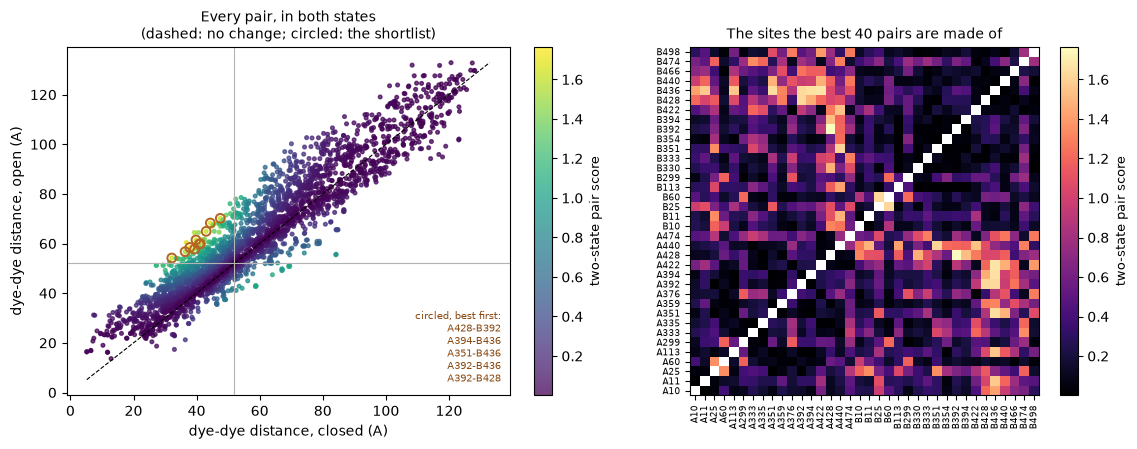

In [19]:
fig, (ax, bx) = plt.subplots(1, 2, figsize=(11.5, 4.6),
                             gridspec_kw={"width_ratios": [1.15, 1.0]})

colours = ax.scatter(d1_av, d2_av, c=[p.value for p in two_av], s=7, cmap="viridis",
                     alpha=0.75)
fig.colorbar(colours, ax=ax, fraction=0.046).set_label("two-state pair score", fontsize=9)
span = [min(d1_av.min(), d2_av.min()), max(d1_av.max(), d2_av.max())]
ax.plot(span, span, "k--", lw=0.8)
ax.axvline(ws.R0, color="0.7", lw=0.8); ax.axhline(ws.R0, color="0.7", lw=0.8)
ax.text(0.98, 0.03, "circled, best first:\n" + "\n".join(name(p) for p in shortlist[:5]),
        transform=ax.transAxes, ha="right", va="bottom", fontsize=7.5, color="#8a4a12")
ax.scatter([p.distance for p in shortlist], [p.distance_2 for p in shortlist],
           s=40, facecolor="none", edgecolor="#b5651d", lw=1.4)
ax.set_xlabel("dye-dye distance, closed (A)")
ax.set_ylabel("dye-dye distance, open (A)")
ax.set_title("Every pair, in both states\n(dashed: no change; circled: the shortlist)",
             fontsize=10)

# the same numbers as a site-by-site matrix, over the sites the best pairs use
matrix_sites = sorted({s for p in two_av[:40]
                       for s in ((p.asym_id_1, p.seq_id_1), (p.asym_id_2, p.seq_id_2))})
index = {site: i for i, site in enumerate(matrix_sites)}
grid = np.full((len(matrix_sites), len(matrix_sites)), np.nan)
for p in two_av:
    a = (p.asym_id_1, p.seq_id_1); b = (p.asym_id_2, p.seq_id_2)
    if a in index and b in index:
        grid[index[a], index[b]] = grid[index[b], index[a]] = p.value
image = bx.imshow(grid, cmap="magma", origin="lower")
fig.colorbar(image, ax=bx, fraction=0.046).set_label("two-state pair score", fontsize=9)
ticks = range(len(matrix_sites))
bx.set_xticks(ticks, [f"{c}{r}" for c, r in matrix_sites], rotation=90, fontsize=6.5)
bx.set_yticks(ticks, [f"{c}{r}" for c, r in matrix_sites], fontsize=6.5)
bx.set_title("The sites the best 40 pairs are made of", fontsize=10)
fig.tight_layout()
plt.show()

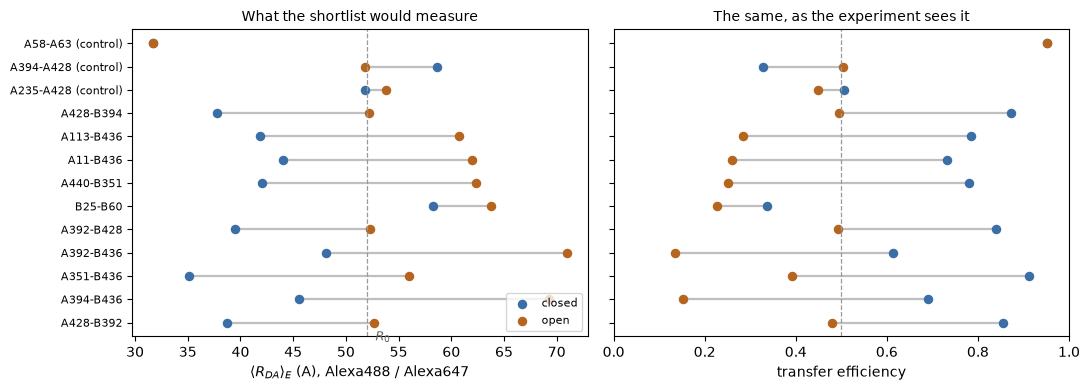

In [20]:
fig, (ax, bx) = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)
labels = [name(p) + (" (control)" if any(p is c for c in controls) else "")
          for p, *_ in checked]
y = np.arange(len(checked))

for row, (_p, rc, ro, ec, eo) in enumerate(checked):
    ax.plot([rc, ro], [row, row], color="0.75", lw=1.6, zorder=1)
    bx.plot([ec, eo], [row, row], color="0.75", lw=1.6, zorder=1)
ax.scatter([r[1] for r in checked], y, s=34, color="#3b6ea5", zorder=2, label="closed")
ax.scatter([r[2] for r in checked], y, s=34, color="#b5651d", zorder=2, label="open")
bx.scatter([r[3] for r in checked], y, s=34, color="#3b6ea5", zorder=2)
bx.scatter([r[4] for r in checked], y, s=34, color="#b5651d", zorder=2)

ax.axvline(ws.R0, color="0.6", lw=0.9, ls="--")
ax.text(ws.R0 + 0.8, -0.8, "$R_0$", color="0.4", fontsize=9)
ax.set_yticks(y, labels, fontsize=8)
ax.set_xlabel(r"$\langle R_{DA}\rangle_E$ (A), Alexa488 / Alexa647")
ax.set_title("What the shortlist would measure", fontsize=10)
ax.legend(fontsize=8, loc="lower right")
bx.axvline(0.5, color="0.6", lw=0.9, ls="--")
bx.set_xlim(0, 1)
bx.set_xlabel("transfer efficiency")
bx.set_title("The same, as the experiment sees it", fontsize=10)
fig.tight_layout()
plt.show()

## The winner, on both structures

The best pair that survives the audit, drawn as the two dye clouds it would
actually put on the protein -- donor in green, acceptor in red -- on the closed
structure and the open one. The volumes are `workshop.av`, the same call the
table above used, so the picture and the numbers cannot drift apart.

If the panels stay blank, Mol* needs internet access from the browser; nothing
else in the notebook depends on it.

In [21]:
winner = shortlist[0]
print(f"{name(winner)}: score {winner.value:.4f}, "
      f"{winner.distance:.1f} A closed -> {winner.distance_2:.1f} A open (screen)")
row = next(r for r in checked if r[0] is winner)
print(f"{'':>{len(name(winner))}}  independent check: {row[1]:.1f} -> {row[2]:.1f} A, "
      f"E {row[3]:.3f} -> {row[4]:.3f}")

panels = []
with quiet():
    for state in ("closed", "open"):
        panels.append(ws.site_panel(
            state,
            [{"chain": winner.asym_id_1, "resi": winner.seq_id_1, "dye": "Alexa488",
              "colour": ws.DONOR_COLOUR},
             {"chain": winner.asym_id_2, "resi": winner.seq_id_2, "dye": "Alexa647",
              "colour": ws.ACCEPTOR_COLOUR}],
            title=f"BmrA {state} ({ws.STATES[state]['pdb_id']}) - {name(winner)}"))
ws.show(panels)

A428-B392: score 1.7652, 37.8 A closed -> 58.4 A open (screen)
           independent check: 38.7 -> 52.7 A, E 0.855 -> 0.480


## One file out

The scores, the pairs and the settings that produced them go into one
`.mmfdb.pto` container rather than a folder of CSVs. It holds the structure
verbatim -- so the coordinates that were scored can be recovered and checked
against a hash, not merely referred to by file name -- the score rows with
their columns named by MMFDB dictionary items, the pair rows, and the complete
settings, model included.

That matters because every number above depends on settings that are easy to
lose: which terms were in the model, the threshold, the probe radius, $R_0$,
which dye model placed the distance. Six CSVs record the numbers and forget the
question. The container is written into a scratch directory, because an example
that writes into the source tree leaves derived files behind that look like
inputs next time.

In [22]:
work = tempfile.mkdtemp()
out = os.path.join(work, "BmrA_closed_open.mmfdb.pto")
settings = bff.labelizer_settings_json(model, bff.LabelizerOptions(),
                                       fret_options(probe_model=bff.PROBE_MODEL_ACCESSIBLE_VOLUME),
                                       "")
with quiet():
    bff.labelizer_write_pto(out, paths["closed"], rows["closed"], two_av[:500], settings)
print(f"{os.path.basename(out)}  {os.path.getsize(out) / 1048576.0:.2f} MB")

with quiet():
    back_scores = bff.labelizer_read_pto_scores(out)
    back_pairs = bff.labelizer_read_pto_pairs(out)
    digest = bff.labelizer_extract_pto_structure(out, os.path.join(work, "recovered.pdb"))
print(f"read back: {len(back_scores)} score rows, {len(back_pairs)} pair rows")
print(f"recovered structure sha256 {digest[:16]}...")
print(f"settings carried: {len(bff.labelizer_read_pto_settings(out))} characters of JSON")

BmrA_closed_open.mmfdb.pto  3.92 MB


read back: 6840 score rows, 500 pair rows
recovered structure sha256 948748851420ad68...
settings carried: 870 characters of JSON


## What to carry forward

* The one-state and the two-state pair scores answer different questions and
  agree on almost nothing. Pick the one that matches the experiment before
  reading any ranking.
* The alpha cone is a screen, not an answer. On BmrA it is unbiased in the
  median and catastrophically wrong on a few sites, which is the failure mode
  that hurts a ranking most.
* `labelizer_pair_scores_two_states` has no refinement tier, so give it
  `probe_model = PROBE_MODEL_ACCESSIBLE_VOLUME` directly: the cost is linear in
  sites, and half a minute buys an exact list.
* A site whose dye has nowhere to go is still scored and still ranked. Audit the
  top of the list before believing it.
* Treat the top of a two-state list as a set of candidates. The order inside it
  moves when the real donor and acceptor geometries are used.

Notebook 3 takes one of these pairs apart: what an accessible volume is, how the
distance is averaged out of it, and where the rotamer libraries come in.